In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

In [266]:
df_raw = pd.read_csv('diabetes_diagnosis.csv')

In [267]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264802 entries, 0 to 264801
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Unnamed: 0            264802 non-null  int64  
 1   CholCheck             113865 non-null  float64
 2   BMI                   177418 non-null  float64
 3   Smoker                145642 non-null  float64
 4   Stroke                105921 non-null  float64
 5   HeartDiseaseorAttack  193306 non-null  float64
 6   PhysActivity          76793 non-null   float64
 7   Fruits                103273 non-null  float64
 8   Veggies               95329 non-null   float64
 9   AnyHealthcare         82089 non-null   float64
 10  NoDocbcCost           66201 non-null   float64
 11  GeneralHealth         195954 non-null  object 
 12  Mental (days)         135050 non-null  float64
 13  Physical (days)       121809 non-null  float64
 14  DiffWalk              121809 non-null  float64
 15  

1. drop index

In [268]:
df_no_index = df_raw.copy()
df_no_index = df_no_index.drop(columns = df_raw.columns[0])
df_no_index.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264802 entries, 0 to 264801
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   CholCheck             113865 non-null  float64
 1   BMI                   177418 non-null  float64
 2   Smoker                145642 non-null  float64
 3   Stroke                105921 non-null  float64
 4   HeartDiseaseorAttack  193306 non-null  float64
 5   PhysActivity          76793 non-null   float64
 6   Fruits                103273 non-null  float64
 7   Veggies               95329 non-null   float64
 8   AnyHealthcare         82089 non-null   float64
 9   NoDocbcCost           66201 non-null   float64
 10  GeneralHealth         195954 non-null  object 
 11  Mental (days)         135050 non-null  float64
 12  Physical (days)       121809 non-null  float64
 13  DiffWalk              121809 non-null  float64
 14  Sex                   195954 non-null  object 
 15  

In [269]:
df_no_index.head()

,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,AnyHealthcare,NoDocbcCost,...,Physical (days),DiffWalk,Sex,Age,Education,Income,Diabetes,BloodPressure,Cholesterol,Alcoholic
0,NaN,40.0,NaN,NaN,0.0,NaN,NaN,NaN,1.0,NaN,...,15.0,NaN,NaN,63.0,High school graduate,"$73,106",No,Yes,Yes,No
1,NaN,25.0,NaN,0.0,0.0,NaN,0.0,NaN,0.0,NaN,...,NaN,NaN,Female,54.0,College graduate,"$22,322",No,No,No,No
2,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,1.0,...,NaN,1.0,NaN,NaN,High school graduate,"$29,097",No,Yes,Yes,NaN
3,1.0,27.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,74.0,Some high school,"$55,498",No,Yes,No,No
4,NaN,24.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,Female,NaN,Some college,"$15,629",No,Yes,NaN,No


In [270]:
df_no_index.isna().mean()

CholCheck               0.569999
BMI                     0.329998
Smoker                  0.449997
Stroke                  0.599999
HeartDiseaseorAttack    0.269998
PhysActivity            0.709998
Fruits                  0.609999
Veggies                 0.639999
AnyHealthcare           0.689999
NoDocbcCost             0.749998
GeneralHealth           0.259998
Mental (days)           0.489996
Physical (days)         0.540000
DiffWalk                0.540000
Sex                     0.259998
Age                     0.239998
Education               0.289998
Income                  0.069999
Diabetes                0.079999
BloodPressure           0.169999
Cholesterol             0.149999
Alcoholic               0.209998
dtype: float64

In [271]:
def col_box_plot (given_serise):
    value_counts = given_serise.value_counts()

    plt.figure(figsize=(4, 3))
    plt.bar(value_counts.index, value_counts.values)
    plt.xlabel('Value')
    plt.ylabel('Number of Cases')
    plt.title('Bar Chart of Column')
    plt.xticks(rotation=45)  # Rotate x labels if too crowded
    plt.show()

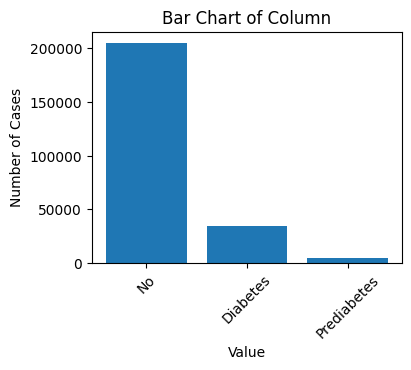

In [272]:
col_box_plot(df_no_index['Diabetes'])

2. throw away samples without labels

In [273]:
df_valid = df_no_index.copy()

In [274]:
def print_unique_class (given_serise):
    print(given_serise.dropna().unique())
    return

In [275]:
# List all labels (classes) first
print_unique_class(df_valid['Diabetes'])

['No' 'Diabetes' 'Prediabetes']


In [276]:
# Drop samples where Diabetes label is missing
# Map "Diabetes" to 2, "Prediabetes"to 1 and "No" to 0
df_valid = df_valid[df_valid['Diabetes'].notna()]
df_valid['Diabetes'] = df_valid['Diabetes'].map({"Diabetes": 2, "Prediabetes": 1, "No": 0})
df_valid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243618 entries, 0 to 264801
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   CholCheck             104654 non-null  float64
 1   BMI                   163281 non-null  float64
 2   Smoker                133929 non-null  float64
 3   Stroke                97525 non-null   float64
 4   HeartDiseaseorAttack  177738 non-null  float64
 5   PhysActivity          70752 non-null   float64
 6   Fruits                95053 non-null   float64
 7   Veggies               87687 non-null   float64
 8   AnyHealthcare         75539 non-null   float64
 9   NoDocbcCost           60890 non-null   float64
 10  GeneralHealth         180244 non-null  object 
 11  Mental (days)         124210 non-null  float64
 12  Physical (days)       112112 non-null  float64
 13  DiffWalk              111995 non-null  float64
 14  Sex                   180208 non-null  object 
 15  Age  

3. str (object) to int

In [277]:
df_str2int = df_valid.copy()

In [278]:
for col in df_str2int.select_dtypes(include=['object']).columns:
    if col == "Income":
        # "Income is a bit special, will be processed later"
        continue
    else:
        df_str2int[col] = df_str2int[col].astype('category')
        df_str2int[col] = df_str2int[col].cat.codes.replace(-1, np.nan) #remain all NaNs unchange

#df_str2int.info()

In [279]:
df_str2int['Income'] = (
    df_str2int['Income']
    .str.replace('$', '', regex=False) # remove dollar sign
    .str.replace(',', '', regex=False) # remove commas
    .astype(float) # convert to float to leave NaNs
)

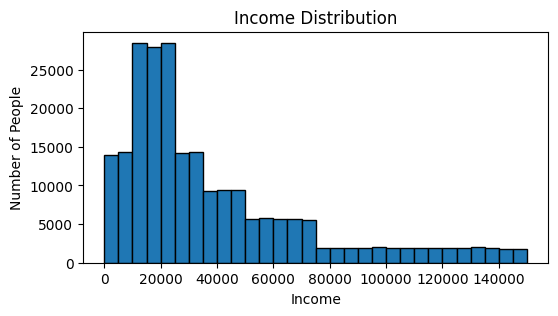

In [280]:
plt.figure(figsize=(6, 3))
plt.hist(df_str2int['Income'].dropna(), bins=30, edgecolor='black')
plt.xlabel('Income')
plt.ylabel('Number of People')
plt.title('Income Distribution')
plt.show()

In [281]:
df_str2int.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243618 entries, 0 to 264801
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   CholCheck             104654 non-null  float64
 1   BMI                   163281 non-null  float64
 2   Smoker                133929 non-null  float64
 3   Stroke                97525 non-null   float64
 4   HeartDiseaseorAttack  177738 non-null  float64
 5   PhysActivity          70752 non-null   float64
 6   Fruits                95053 non-null   float64
 7   Veggies               87687 non-null   float64
 8   AnyHealthcare         75539 non-null   float64
 9   NoDocbcCost           60890 non-null   float64
 10  GeneralHealth         180244 non-null  float64
 11  Mental (days)         124210 non-null  float64
 12  Physical (days)       112112 non-null  float64
 13  DiffWalk              111995 non-null  float64
 14  Sex                   180208 non-null  float64
 15  Age  

In [282]:
df_str2int.head()

,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,AnyHealthcare,NoDocbcCost,...,Physical (days),DiffWalk,Sex,Age,Education,Income,Diabetes,BloodPressure,Cholesterol,Alcoholic
0,NaN,40.0,NaN,NaN,0.0,NaN,NaN,NaN,1.0,NaN,...,15.0,NaN,NaN,63.0,2.0,73106.0,0,1.0,1.0,0.0
1,NaN,25.0,NaN,0.0,0.0,NaN,0.0,NaN,0.0,NaN,...,NaN,NaN,0.0,54.0,0.0,22322.0,0,0.0,0.0,0.0
2,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,1.0,...,NaN,1.0,NaN,NaN,2.0,29097.0,0,1.0,1.0,NaN
3,1.0,27.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,74.0,5.0,55498.0,0,1.0,0.0,0.0
4,NaN,24.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,NaN,4.0,15629.0,0,1.0,NaN,0.0


Dot plt all features

In [283]:
def dot_plt_all_features (given_df):
    cols = given_df.columns
    n_cols = 4  # number of plots in one row
    n_rows = (len(cols) + n_cols - 1) // n_cols  # calculate number of rows needed

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))

    # If axes is 1D (only 1 row), make it 2D for easier looping
    axes = axes.reshape(-1)

    for i, col in enumerate(cols):
        ax = axes[i]
        ax.plot(given_df.index, given_df[col], 'o')
        ax.set_title(col)
        ax.set_xlabel('Index')
        ax.set_ylabel(col)

    # Hide any empty subplots (if number of columns isn't divisible by 4)
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

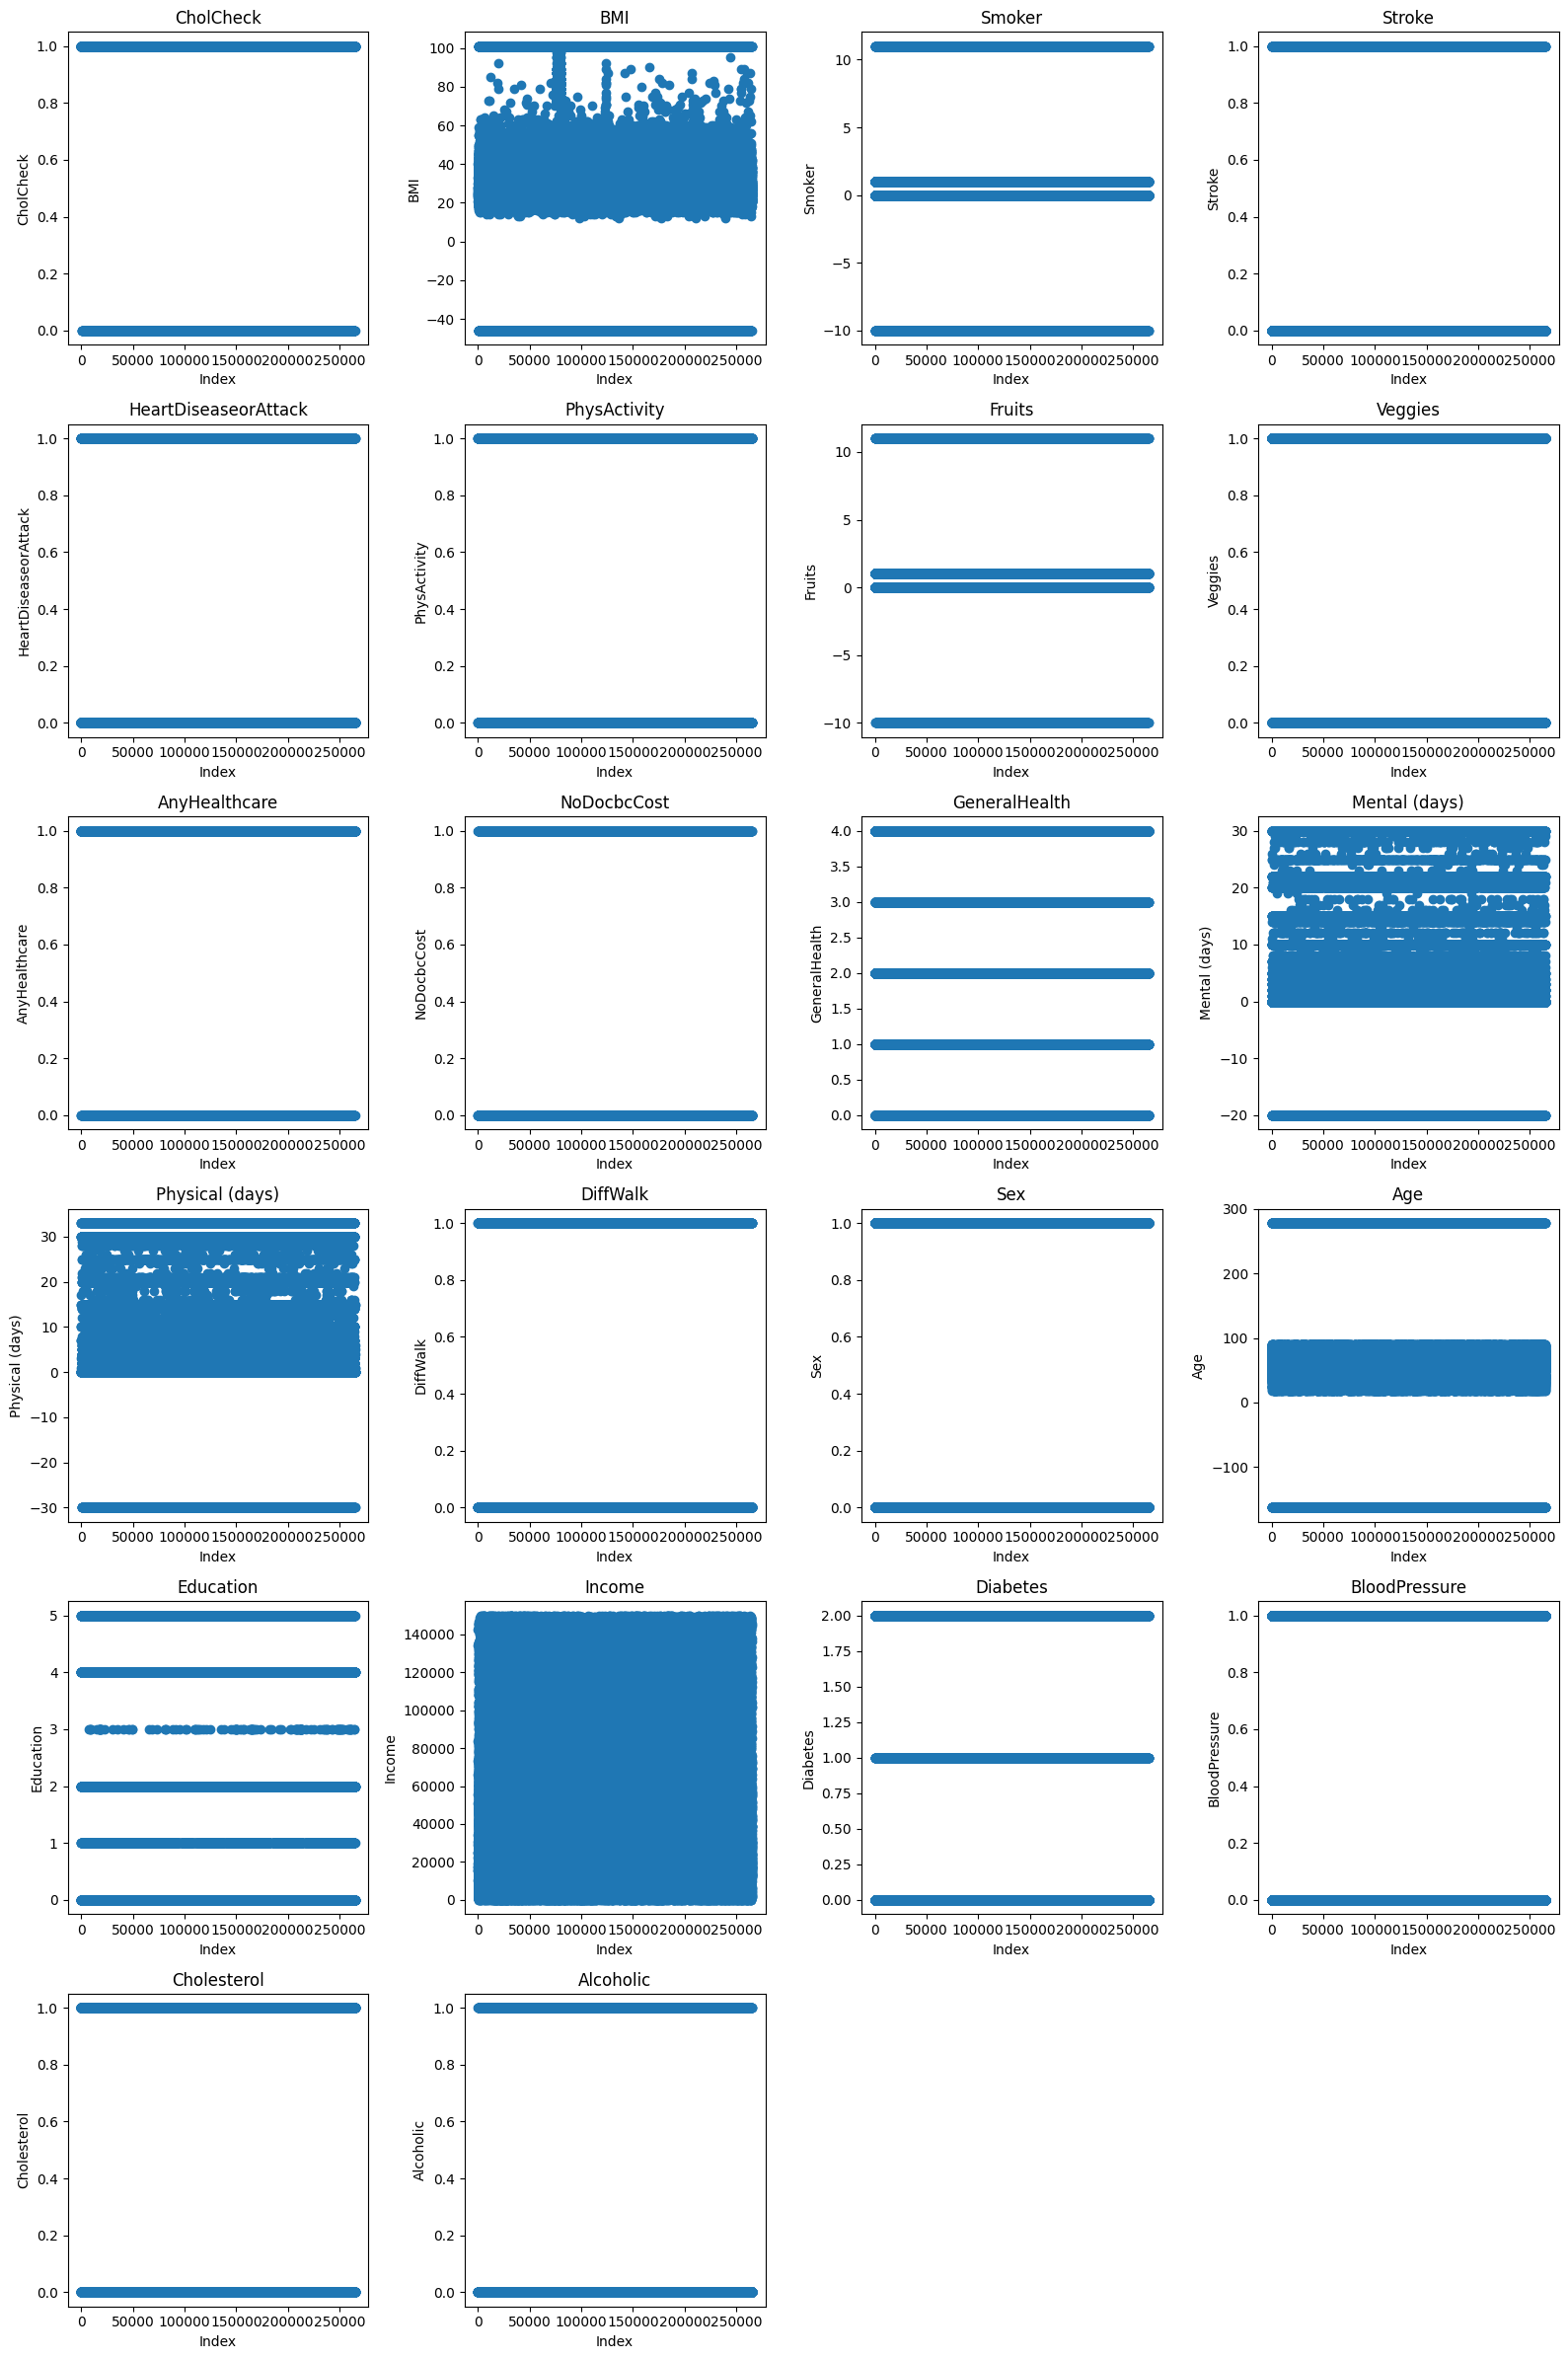

In [284]:
dot_plt_all_features (df_str2int)

In [285]:
print(df_no_index.columns)

Index(['CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
       'PhysActivity', 'Fruits', 'Veggies', 'AnyHealthcare', 'NoDocbcCost',
       'GeneralHealth', 'Mental (days)', 'Physical (days)', 'DiffWalk', 'Sex',
       'Age', 'Education', 'Income', 'Diabetes', 'BloodPressure',
       'Cholesterol', 'Alcoholic'],
      dtype='object')


About "BMI"

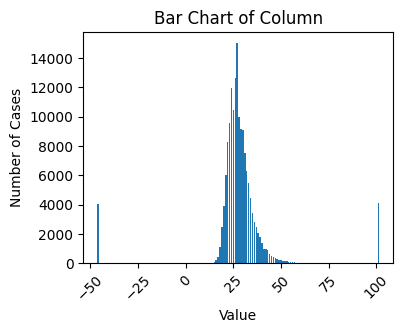

In [286]:
col_box_plot (df_str2int['BMI'])

In [287]:
df_BMI = df_str2int.copy()

In [288]:
df_BMI['BMI'] = df_BMI['BMI'].replace(-46, np.nan)
df_BMI['BMI'] = df_BMI['BMI'].replace(101, np.nan)

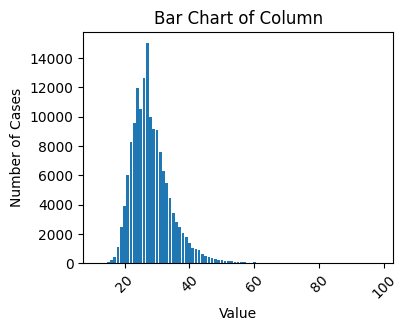

In [289]:
col_box_plot (df_BMI['BMI'])

About Smoker

In [290]:
df_smoker = df_BMI.copy()

In [291]:
print_unique_class(df_smoker['Smoker'])

[  1.   0.  11. -10.]


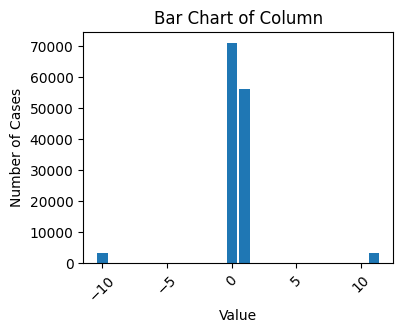

In [292]:
col_box_plot(df_smoker['Smoker'])

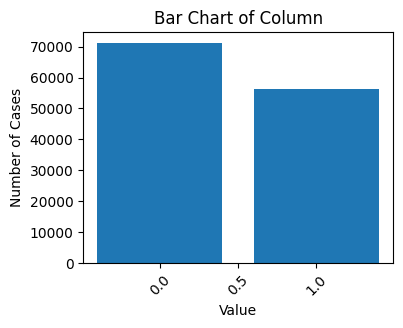

In [293]:
df_smoker['Smoker'] = df_smoker['Smoker'].replace(-10, np.nan)
df_smoker['Smoker'] = df_smoker['Smoker'].replace(11 , np.nan)
col_box_plot(df_smoker['Smoker'])

In [294]:
print_unique_class(df_smoker['Stroke'])
print_unique_class(df_smoker['HeartDiseaseorAttack'])
print_unique_class(df_smoker['PhysActivity'])
print_unique_class(df_smoker['Fruits']) # unnormal detected

[0. 1.]
[0. 1.]
[0. 1.]
[  0.   1.  11. -10.]


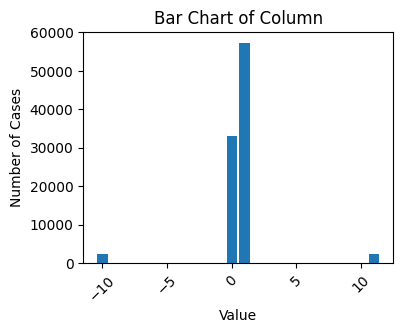

In [295]:
df_Fruits = df_smoker.copy()
col_box_plot(df_Fruits['Fruits'])

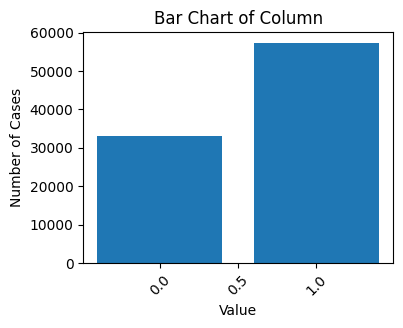

In [296]:
df_Fruits['Fruits'] = df_Fruits['Fruits'].replace(-10, np.nan)
df_Fruits['Fruits'] = df_Fruits['Fruits'].replace(11 , np.nan)
col_box_plot(df_Fruits['Fruits'])

In [297]:
print_unique_class(df_smoker['Veggies'])
print_unique_class(df_smoker['AnyHealthcare'])
print_unique_class(df_smoker['NoDocbcCost'])
print_unique_class(df_smoker['GeneralHealth']) # order variable, correct the order by remapping

[1. 0.]
[1. 0.]
[1. 0.]
[2. 3. 4. 1. 0.]


In [298]:
print_unique_class(df_valid['GeneralHealth'])

['Good' 'Poor' 'Very Good' 'Fair' 'Excellent']


In [299]:
# Orginally, .castype('category').cat is done in alphabetical order, which is:
# Excellent -> 0
# Fair -> 1
# Good -> 2
# Poor -> 3
# Very Good -> 4

# remap it as:
# Excellent -> 4
# Fair -> 1
# Good -> 2
# Poor -> 0
# Very Good -> 3

df_GeneralHealth = df_Fruits.copy()
GH_mapping = {0: 4, 3: 0, 4: 3}
df_GeneralHealth['GeneralHealth'] = df_GeneralHealth['GeneralHealth'].replace(GH_mapping)

In [300]:
print_unique_class(df_GeneralHealth['GeneralHealth'])
# should be 2, 0, 3, 1, 4

[2. 0. 3. 1. 4.]


In [301]:
print_unique_class(df_GeneralHealth['DiffWalk'])
print_unique_class(df_GeneralHealth['Sex'])
print_unique_class(df_GeneralHealth['Education']) # order variable, correct the order by remapping

[1. 0.]
[0. 1.]
[2. 0. 5. 4. 1. 3.]


In [302]:
print_unique_class(df_valid['Education'])

['High school graduate' 'College graduate' 'Some high school'
 'Some college' 'Elementary' 'Never attended school']


In [303]:
# Orginally, .castype('category').cat is done in alphabetical order, which is:
# College graduate      -> 0
# Elementary            -> 1
# High school graduate  -> 2
# Never attended school -> 3
# Some college          -> 4
# Some high school      -> 5

# remap it as:
# College graduate      -> 5
# Elementary            -> 1
# High school graduate  -> 3
# Never attended school -> 0
# Some college          -> 4
# Some high school      -> 2

df_Education = df_GeneralHealth.copy()
edu_mapping = {0:5, 2:3, 3:0, 5:2}
df_Education['Education'] = df_Education['Education'] .replace(edu_mapping)

In [304]:
print_unique_class(df_Education['Education'])
# should be 3, 5, 2, 4, 1, 0

[3. 5. 2. 4. 1. 0.]


In [305]:
print_unique_class(df_Education['BloodPressure'])
print_unique_class(df_Education['Cholesterol'])
print_unique_class(df_Education['Alcoholic'])

[1. 0.]
[1. 0.]
[0. 1.]


In [306]:
df_Education.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243618 entries, 0 to 264801
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   CholCheck             104654 non-null  float64
 1   BMI                   155137 non-null  float64
 2   Smoker                127251 non-null  float64
 3   Stroke                97525 non-null   float64
 4   HeartDiseaseorAttack  177738 non-null  float64
 5   PhysActivity          70752 non-null   float64
 6   Fruits                90303 non-null   float64
 7   Veggies               87687 non-null   float64
 8   AnyHealthcare         75539 non-null   float64
 9   NoDocbcCost           60890 non-null   float64
 10  GeneralHealth         180244 non-null  float64
 11  Mental (days)         124210 non-null  float64
 12  Physical (days)       112112 non-null  float64
 13  DiffWalk              111995 non-null  float64
 14  Sex                   180208 non-null  float64
 15  Age  

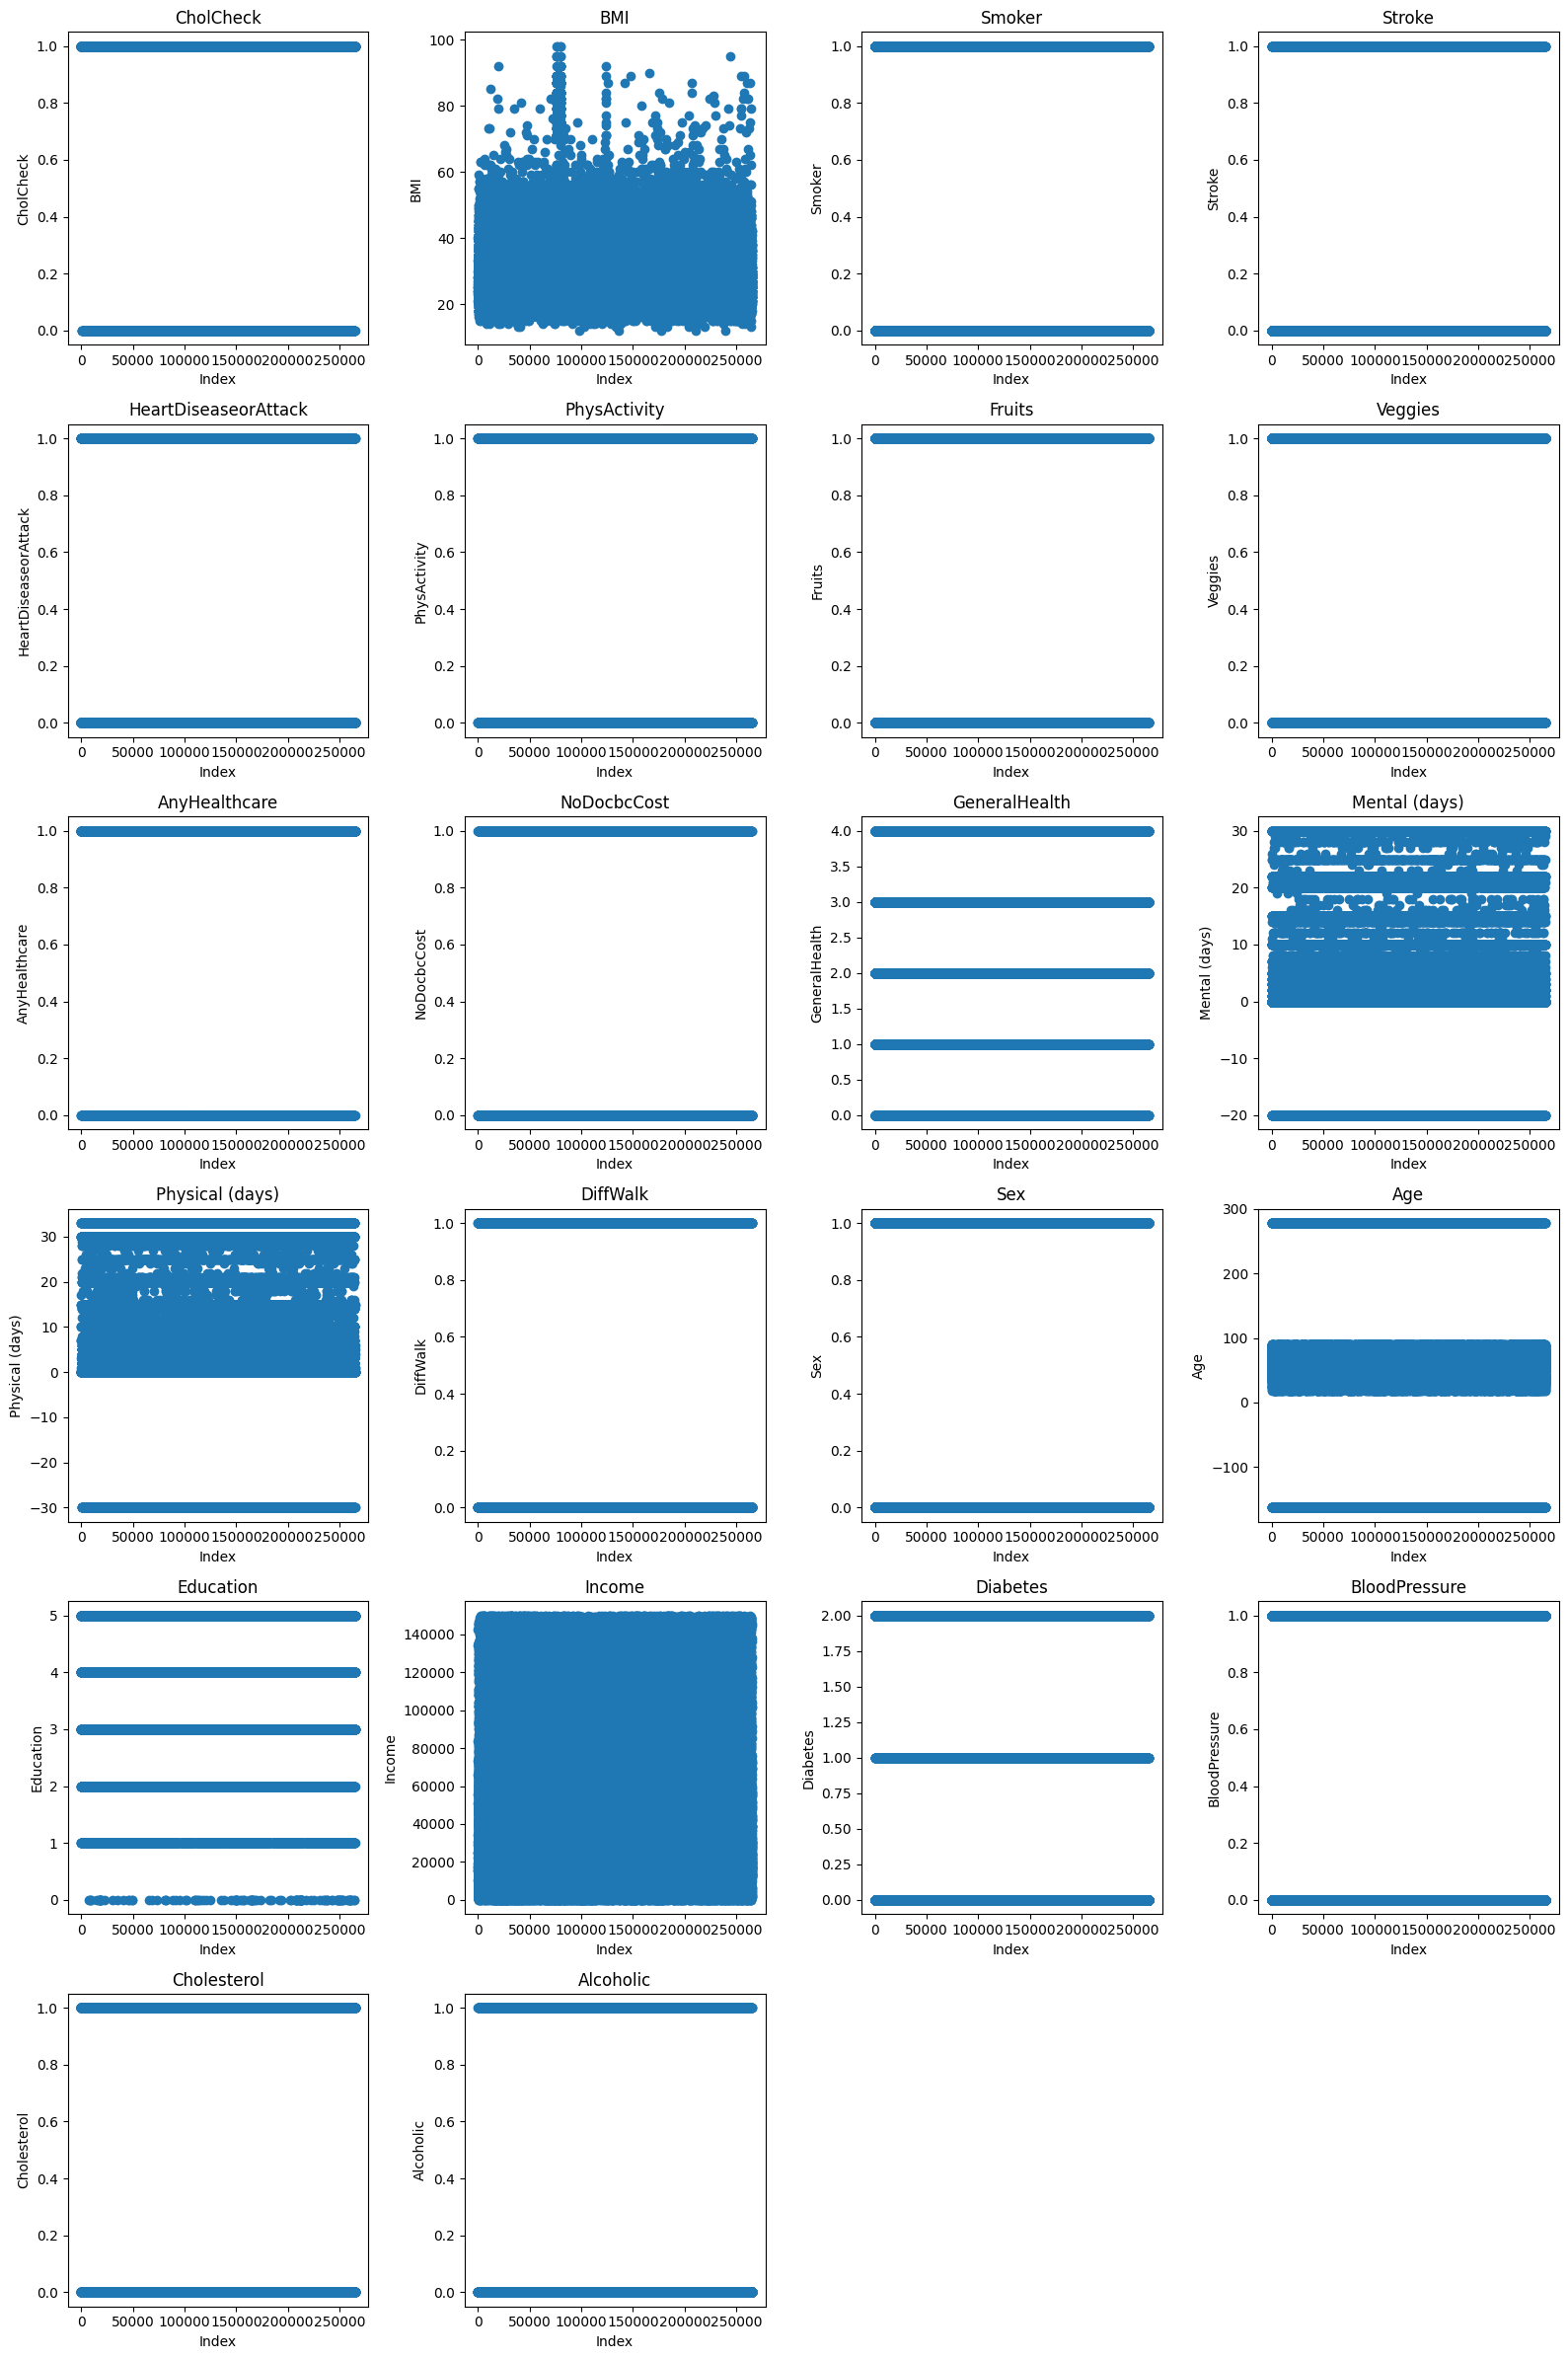

In [307]:
dot_plt_all_features (df_Education)

Still strange data in 'Mental (days)', 'Physical (days)' and 'Age'

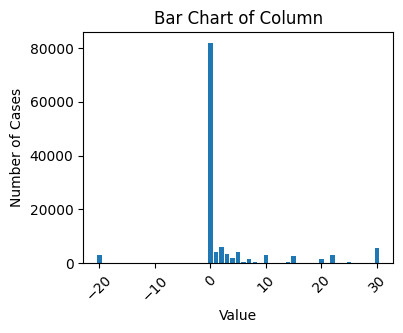

30.0


In [308]:
df_Mental_days = df_Education.copy()
col_box_plot(df_Mental_days['Mental (days)'])
print(df_Mental_days['Mental (days)'].max())

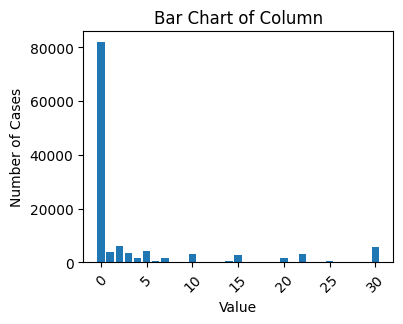

In [309]:
df_Mental_days.loc[df_Mental_days['Mental (days)'] < 0, 'Mental (days)'] = np.nan
col_box_plot(df_Mental_days['Mental (days)'])

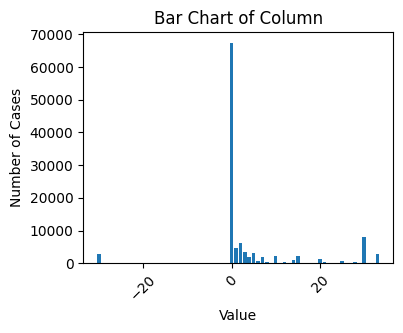

In [310]:
df_Physical_days = df_Mental_days.copy()
col_box_plot(df_Physical_days['Physical (days)'])

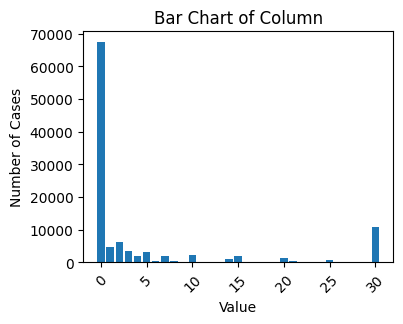

In [311]:
df_Physical_days.loc[df_Physical_days['Physical (days)'] < 0, 'Physical (days)'] = np.nan
df_Physical_days.loc[df_Physical_days['Physical (days)'] > 30, 'Physical (days)'] = 30
col_box_plot(df_Physical_days['Physical (days)'])

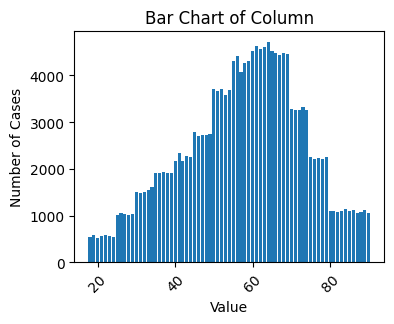

In [312]:
df_Age = df_Physical_days.copy()
df_Age.loc[df_Age['Age'] < 0  , 'Age'] = np.nan
df_Age.loc[df_Age['Age'] > 120, 'Age'] = np.nan
col_box_plot(df_Age['Age'])

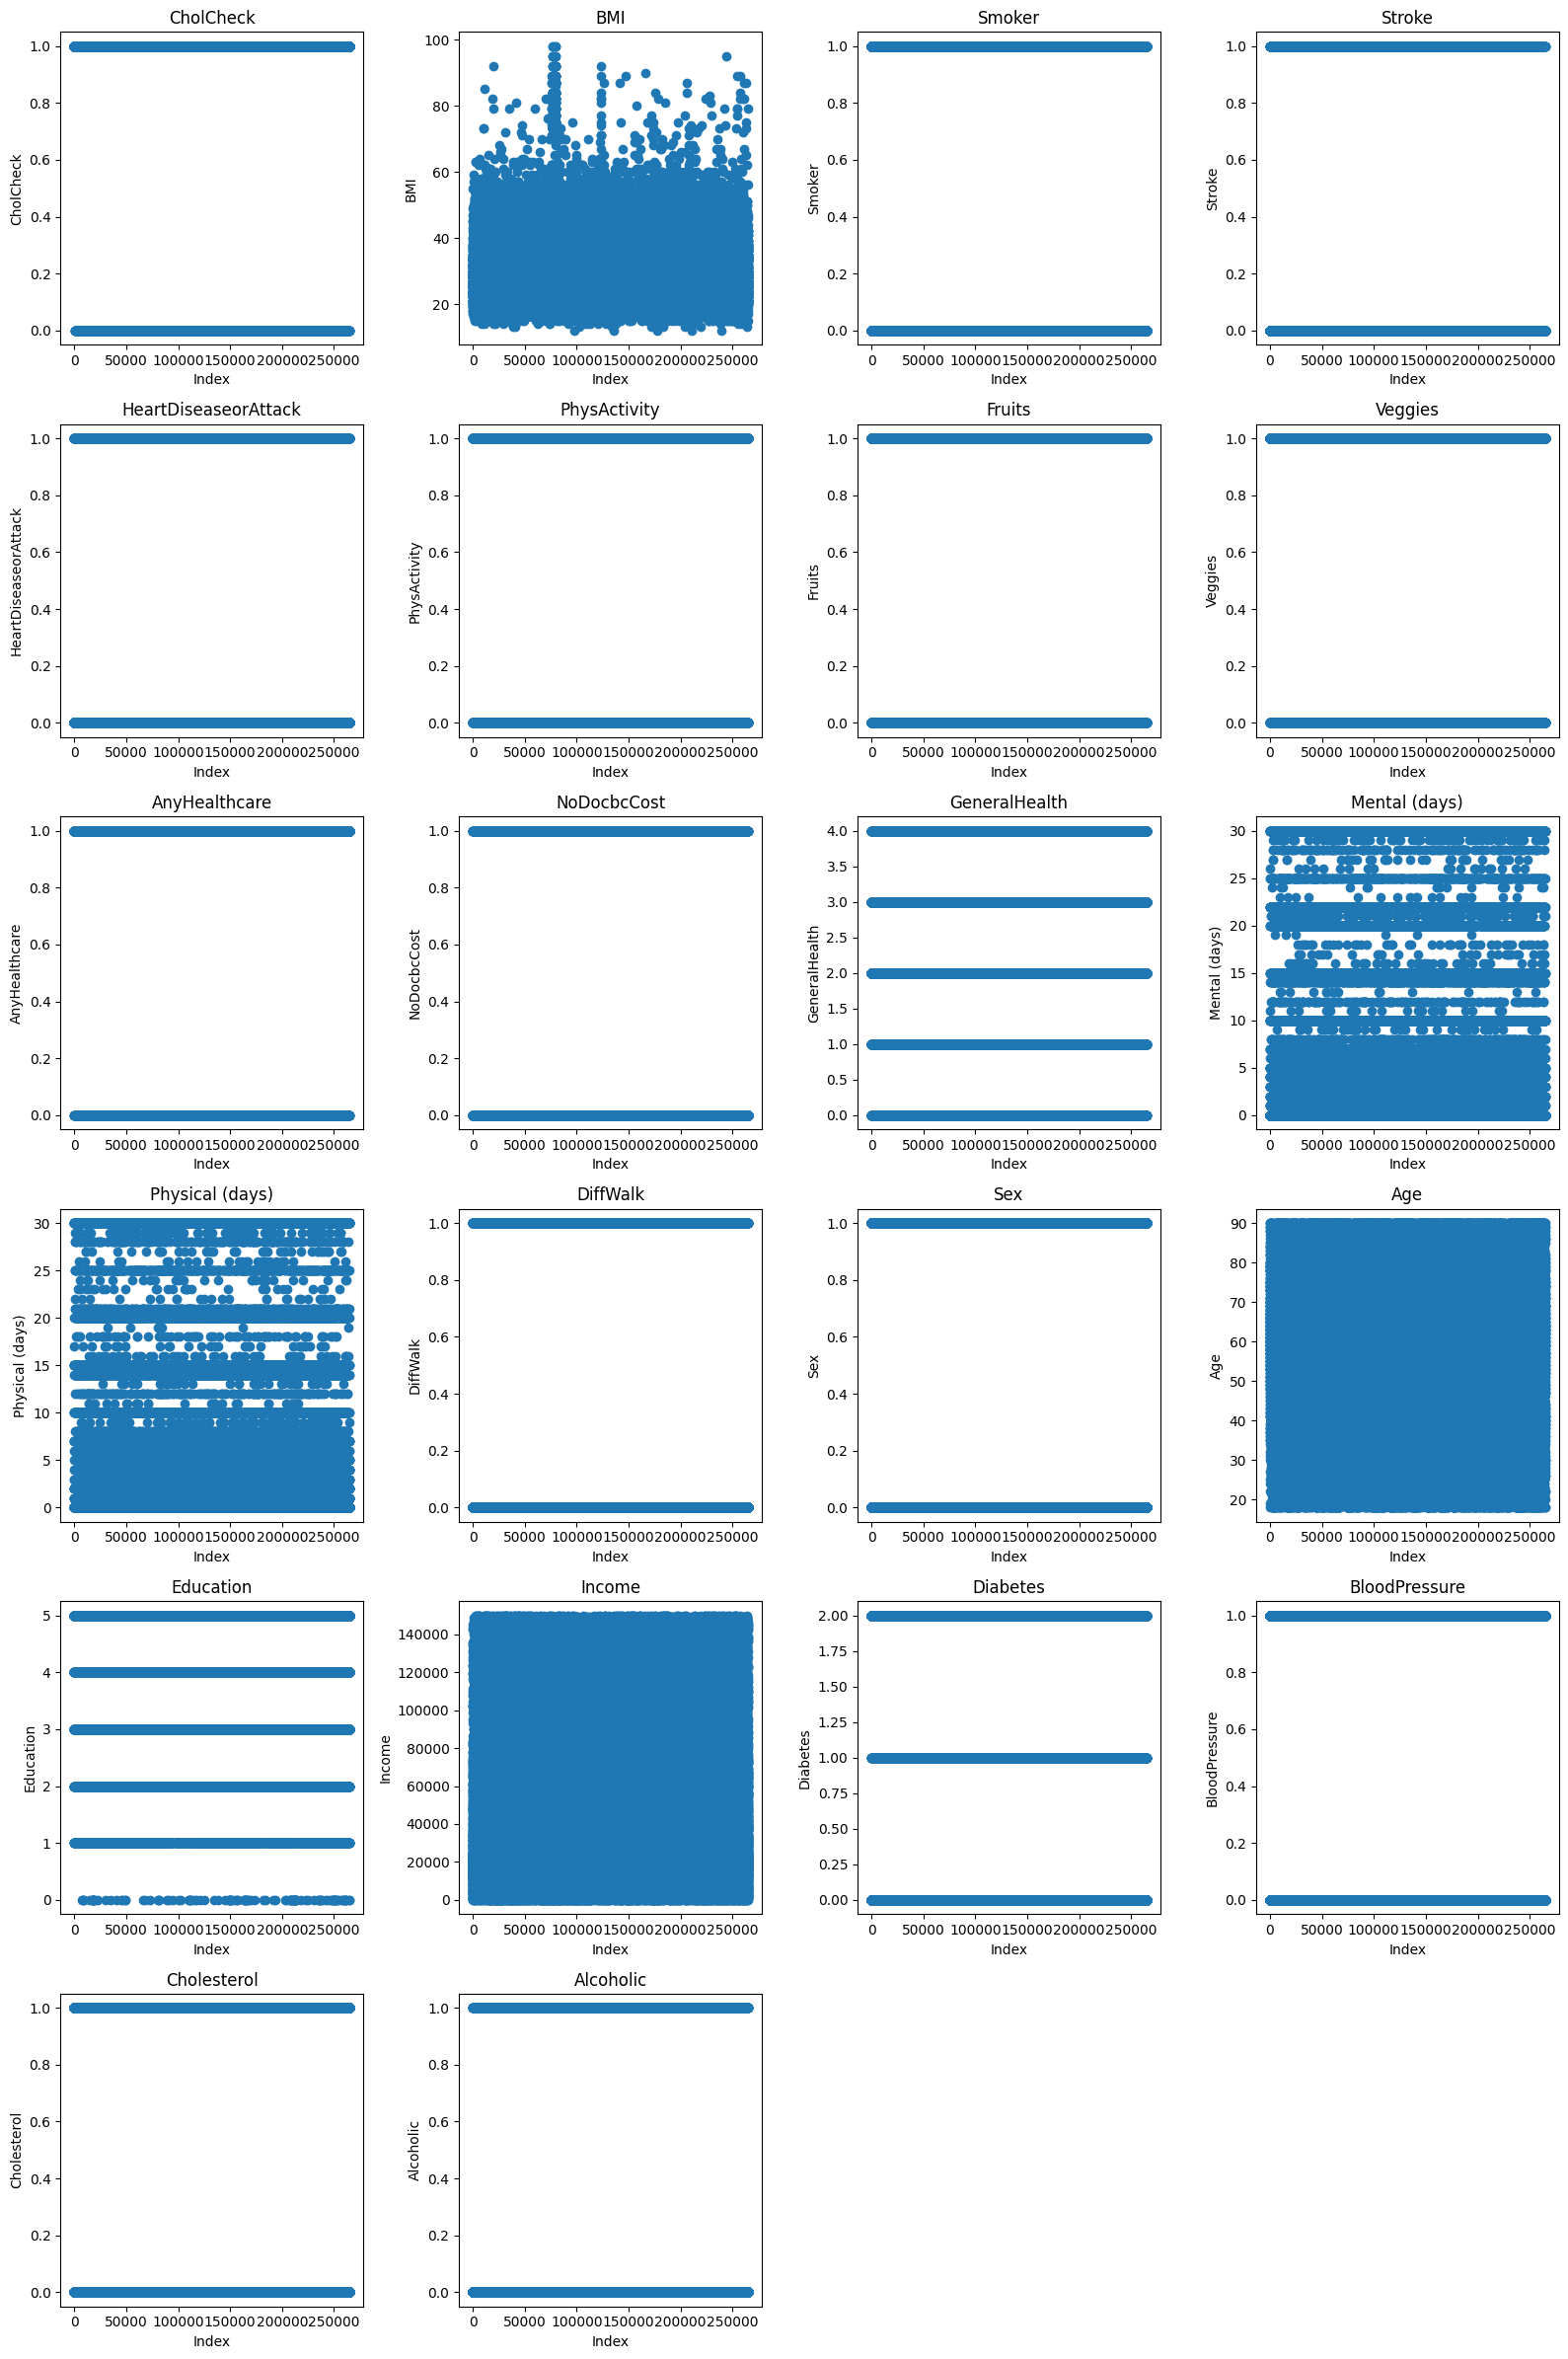

In [313]:
dot_plt_all_features (df_Age)

check outliers with box plot

In [314]:
def box_plot_all_features(given_df):
    cols_to_plot = given_df.columns  # all columns
    n_cols = 8  # 4 plots per row
    n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols  # calculate how many rows

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))

    # Flatten axes array (works even if 1D or 2D)
    axes = axes.flatten()

    # Plot each feature
    for i, col in enumerate(cols_to_plot):
        ax = axes[i]
        ax.boxplot(given_df[col].dropna())
        ax.set_title(col)
        ax.set_ylabel('Value')

    # Hide any empty subplots if total columns < n_rows*n_cols
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

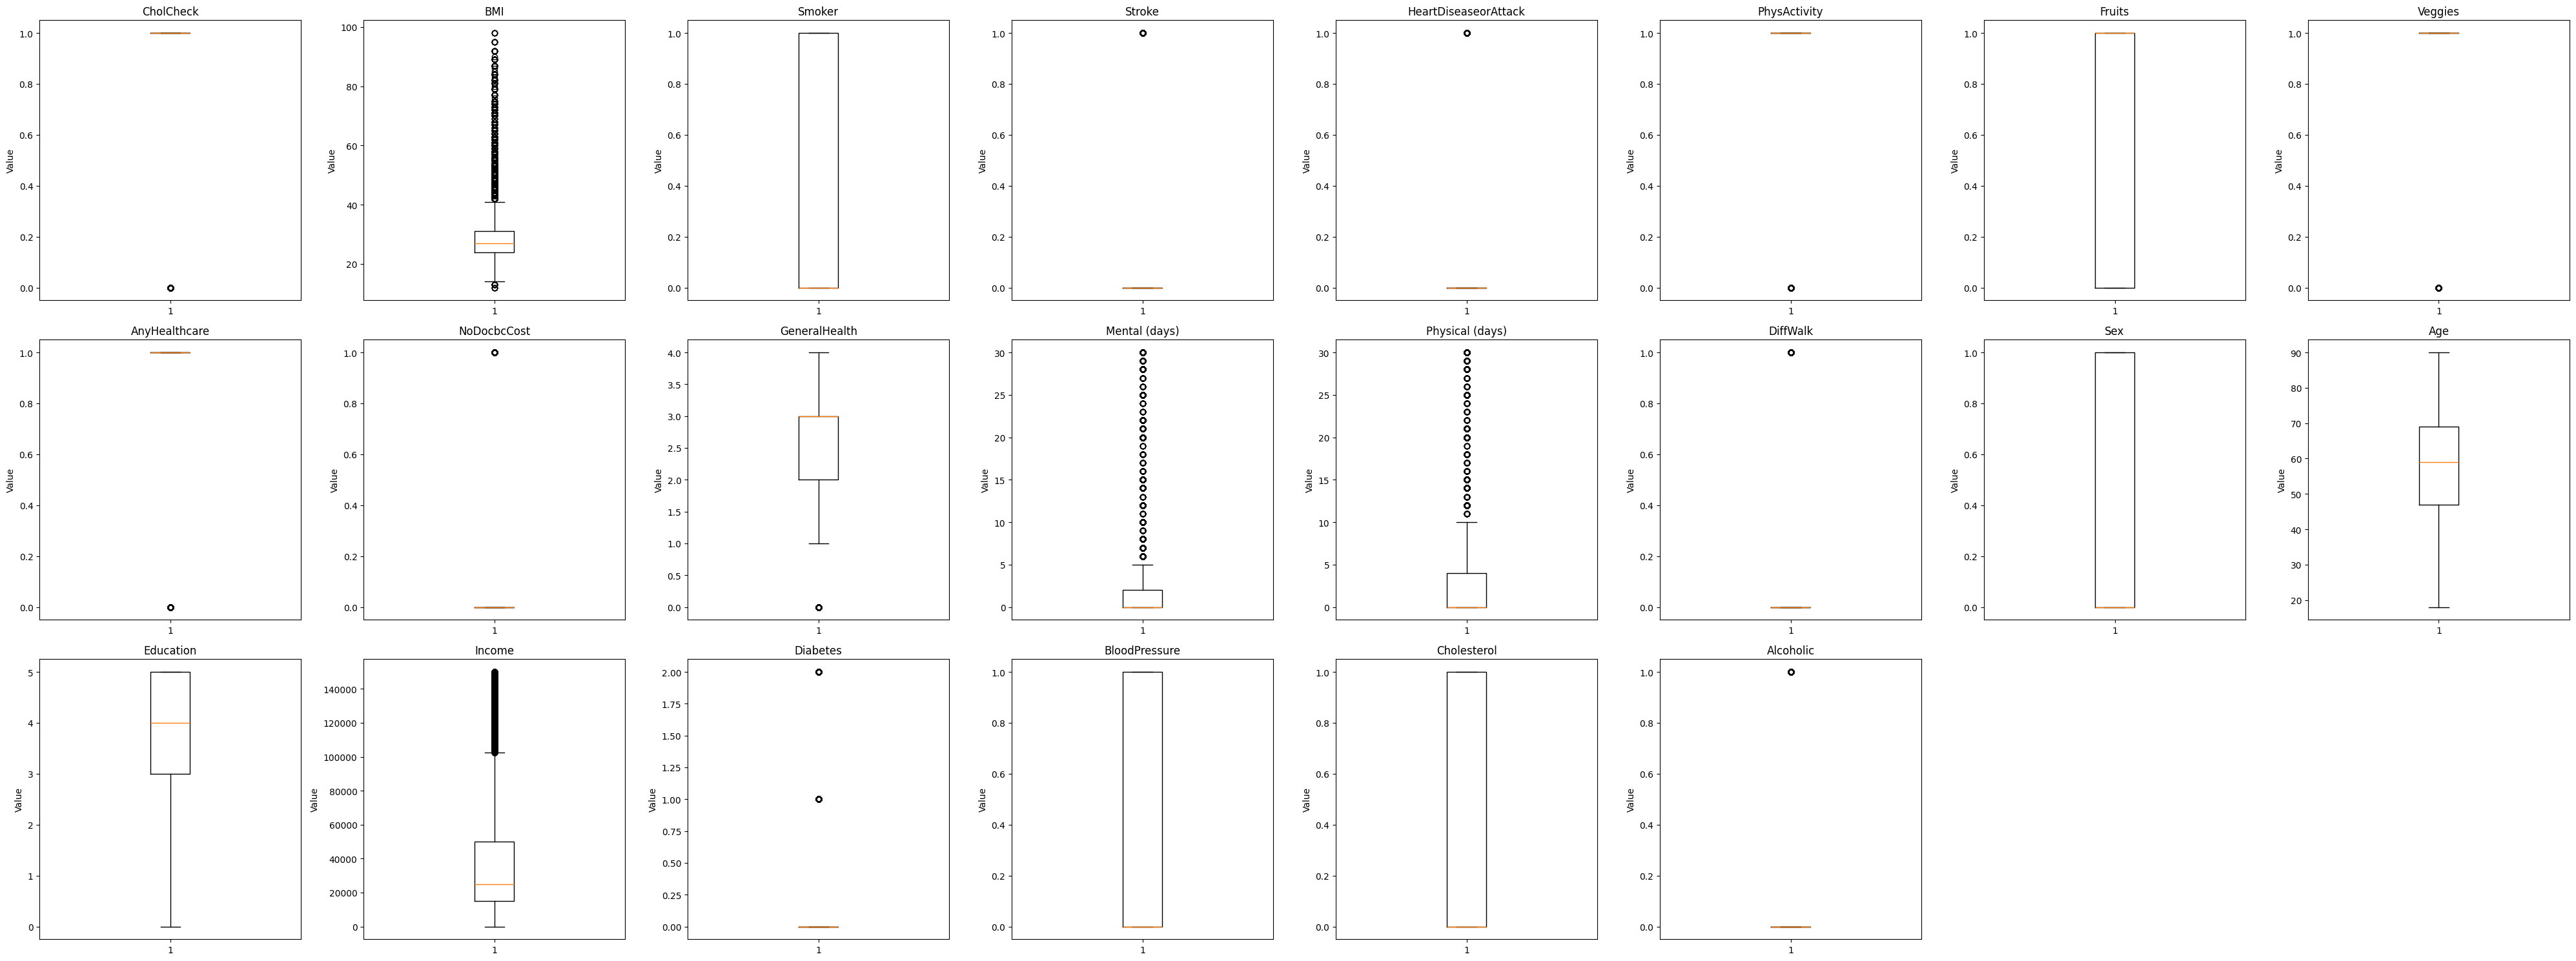

In [315]:
box_plot_all_features(df_Age)

Finish Data Validation.

Missing Value Handling

In [328]:
df_drop_NA = df_Age.copy()
df_drop_NA.isna().mean()

CholCheck               0.570418
BMI                     0.363196
Smoker                  0.477662
Stroke                  0.599681
HeartDiseaseorAttack    0.270423
PhysActivity            0.709578
Fruits                  0.629325
Veggies                 0.640064
AnyHealthcare           0.689928
NoDocbcCost             0.750060
GeneralHealth           0.260137
Mental (days)           0.502841
Physical (days)         0.551679
DiffWalk                0.540284
Sex                     0.260285
Age                     0.277627
Education               0.289942
Income                  0.069777
Diabetes                0.000000
BloodPressure           0.170184
Cholesterol             0.150009
Alcoholic               0.210017
dtype: float64

In [329]:
# drop cols with NaN more than 70%
# also drop 'AnyHealthcare' for very close to 70%
df_drop_NA = df_drop_NA.drop(columns=['PhysActivity', 'NoDocbcCost', 'AnyHealthcare'])

In [330]:
def fill_nan_with_mode(df, col_name):
    mode_value = df[col_name].mode().iloc[0]
    df[col_name] = df[col_name].fillna(mode_value)
    return df

def fill_nan_with_median(df, col_name):
    median_value = df[col_name].median()
    df[col_name] = df[col_name].fillna(median_value)
    return df

In [331]:
df_drop_NA.columns

Index(['CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
       'Fruits', 'Veggies', 'GeneralHealth', 'Mental (days)',
       'Physical (days)', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'Diabetes', 'BloodPressure', 'Cholesterol', 'Alcoholic'],
      dtype='object')

In [332]:
col_of_NaN_2_median = ['BMI', 'Mental (days)', 'Physical (days)', 'Age','Income']
col_of_NaN_2_mode = ['CholCheck', 
                     'Smoker', 
                     'Stroke', 
                     'HeartDiseaseorAttack', 
                     'Fruits', 
                     'Veggies', 
                     'GeneralHealth', 
                     'DiffWalk', 
                     'Sex', 
                     'Age', 
                     'Education',  
                     'BloodPressure', 
                     'Cholesterol', 
                     'Alcoholic']

for each_col in col_of_NaN_2_median:
    df_drop_NA = fill_nan_with_median(df_drop_NA, each_col)

for each_col in col_of_NaN_2_mode:
    df_drop_NA = fill_nan_with_mode(df_drop_NA, each_col)


In [333]:
NaN_percent = df_drop_NA.isna().mean()
print(NaN_percent)

CholCheck               0.0
BMI                     0.0
Smoker                  0.0
Stroke                  0.0
HeartDiseaseorAttack    0.0
Fruits                  0.0
Veggies                 0.0
GeneralHealth           0.0
Mental (days)           0.0
Physical (days)         0.0
DiffWalk                0.0
Sex                     0.0
Age                     0.0
Education               0.0
Income                  0.0
Diabetes                0.0
BloodPressure           0.0
Cholesterol             0.0
Alcoholic               0.0
dtype: float64


In [334]:
# Drop rows where all features (excluding 'Label') are NaN
df_drop_empty_sample = df_drop_NA.copy()

In [335]:
df_drop_empty_sample = df_drop_empty_sample.dropna(subset=[col for col in df_drop_empty_sample.columns if col != 'Diabetes'], how='all')
df_drop_empty_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243618 entries, 0 to 264801
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   CholCheck             243618 non-null  float64
 1   BMI                   243618 non-null  float64
 2   Smoker                243618 non-null  float64
 3   Stroke                243618 non-null  float64
 4   HeartDiseaseorAttack  243618 non-null  float64
 5   Fruits                243618 non-null  float64
 6   Veggies               243618 non-null  float64
 7   GeneralHealth         243618 non-null  float64
 8   Mental (days)         243618 non-null  float64
 9   Physical (days)       243618 non-null  float64
 10  DiffWalk              243618 non-null  float64
 11  Sex                   243618 non-null  float64
 12  Age                   243618 non-null  float64
 13  Education             243618 non-null  float64
 14  Income                243618 non-null  float64
 15  Diabe

Finish Missing Handling

Final. Check and drop duplicated samples

In [336]:
df_no_dup = df_drop_empty_sample.copy()
duplicates = df_no_dup.duplicated()
print(duplicates.sum())

2433


In [337]:
df_no_dup = df_no_dup.drop_duplicates()

In [338]:
duplicates = df_no_dup.duplicated()
print(duplicates.sum())

0


In [339]:
df_no_dup.info()

<class 'pandas.core.frame.DataFrame'>
Index: 241185 entries, 0 to 264801
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   CholCheck             241185 non-null  float64
 1   BMI                   241185 non-null  float64
 2   Smoker                241185 non-null  float64
 3   Stroke                241185 non-null  float64
 4   HeartDiseaseorAttack  241185 non-null  float64
 5   Fruits                241185 non-null  float64
 6   Veggies               241185 non-null  float64
 7   GeneralHealth         241185 non-null  float64
 8   Mental (days)         241185 non-null  float64
 9   Physical (days)       241185 non-null  float64
 10  DiffWalk              241185 non-null  float64
 11  Sex                   241185 non-null  float64
 12  Age                   241185 non-null  float64
 13  Education             241185 non-null  float64
 14  Income                241185 non-null  float64
 15  Diabe

In [343]:
df_no_dup.to_csv("diabetes_clean.csv", index = False)

Finish Basic Pre-processing

Some features:
1. Imbalance 

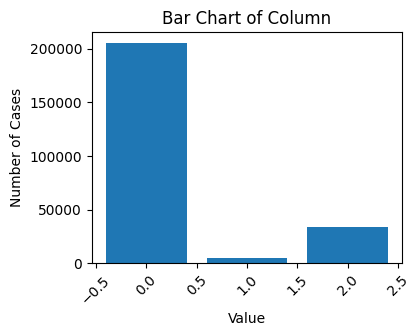

In [340]:
col_box_plot(df_Mental_days['Diabetes'])

2. Feature Correlation

In [341]:
selected_features = ['CholCheck', 
                    'BMI', 
                    'Smoker', 
                    'Stroke',
                    'HeartDiseaseorAttack',
                    'Fruits', 
                    'Veggies', 
                    'GeneralHealth', 
                    'Mental (days)',
                    'Physical (days)', 
                    'DiffWalk', 
                    'Sex', 
                    'Age', 
                    'Education', 
                    'Income',
                    'BloodPressure', 
                    'Cholesterol', 
                    'Alcoholic',
                    'Diabetes'
                    ]

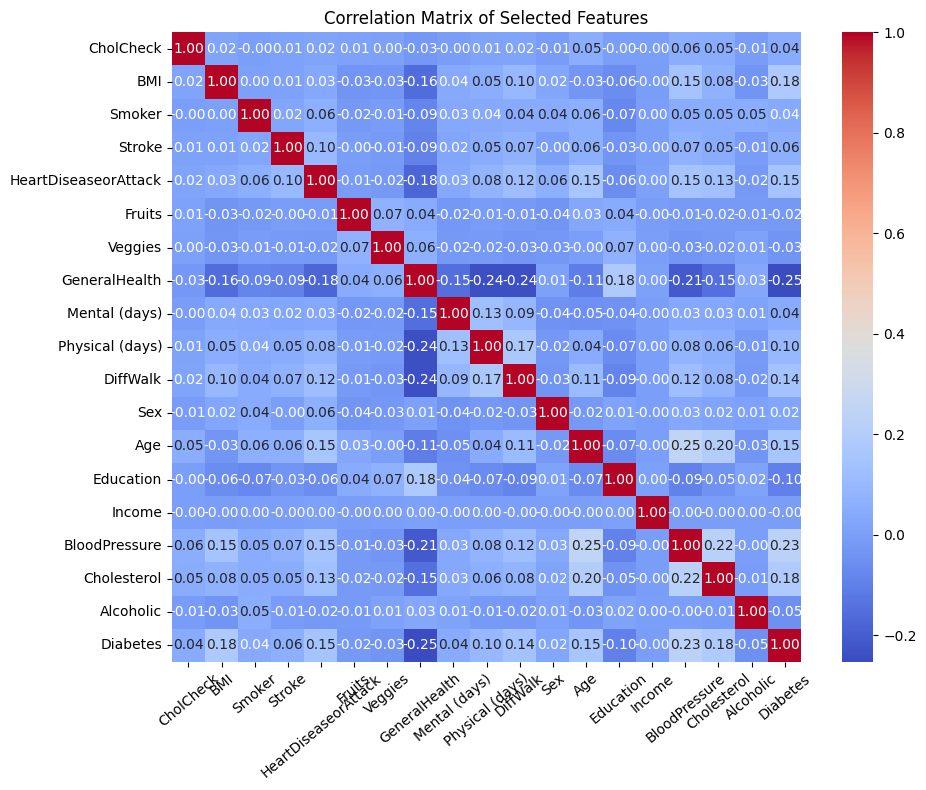

In [ ]:
corr_matrix = df_no_dup[selected_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Matrix of Selected Features")
plt.xticks(rotation=40)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

Prety good, no high-correlated groups